# Index Management — End-to-End Demo

This notebook walks through all four workflows in the `index_management` package:

1. **Universe** — resolve ISIN codes to ticker symbols
2. **Market** — fetch prices and market caps from Yahoo Finance
3. **Strategy** — compute portfolio weights (Cap-Weighted & Max Sharpe Ratio)
4. **Valuation** — convert weights + prices into share counts and portfolio value

Each section corresponds to its detailed driver notebook in `index_management/drivers/`.

In [ ]:
import sys, os
_nb = globals().get("__vsc_ipynb_file__", "")
_root = os.path.dirname(os.path.abspath(_nb)) if _nb else os.getcwd()
if _root not in sys.path:
    sys.path.insert(0, _root)
os.chdir(_root)

In [1]:
TARGET_DATE = "20250331"  # change this to run a different quarter

## 1 · Universe

Maps ISIN codes in `data/universe/raw/` to Yahoo Finance ticker symbols and writes `data/universe/processed/`.

In [2]:
from index_management.universe.Manager import Universe
from index_management.utilities.utils import fullpath, get_datestr
import pandas as pd

unv = Universe(TARGET_DATE)

# Read the already-processed universe (run get_raw_universe() to refresh from source)
unv_path = fullpath(unv.path_universe("processed"), get_datestr(TARGET_DATE) + ".csv")
df_universe = pd.read_csv(unv_path)
print(f"{len(df_universe)} securities in universe")
df_universe.head()

40 securities in universe


,Code ISIN,Code Sicovam,Valeur,symbol
0,FR0000120404,12040,ACCOR,AC.PA
1,FR0000120073,12007,AIR LIQUIDE,AI.PA
2,NL0000235190,5730,Airbus Group (ex-EADS),AIR.PA
3,LU0323134006,32313400,ArcelorMittal,MT.AS
4,FR0000120628,12062,Axa,CS.PA


## 2 · Market

Fetches closing prices and market caps from Yahoo Finance for all universe members.

In [3]:
from index_management.market.Manager import Market

mkt = Market(TARGET_DATE)

# Read cached market data (call mkt.get_prices() / mkt.get_caps() to refresh)
import pandas as pd
from index_management.utilities.utils import fullpath, get_datestr

prices = pd.read_csv(fullpath("data", "market", "prices", get_datestr(TARGET_DATE) + ".csv"), index_col=0)
caps   = pd.read_csv(fullpath("data", "market", "caps",   get_datestr(TARGET_DATE) + ".csv"))

print(f"Price history shape: {prices.shape}")
print(f"Market caps: {len(caps)} symbols")
caps.head()

Price history shape: (83, 40)
Market caps: 40 symbols


,Symbol,MarketCap
0,AC.PA,9541465088
1,AI.PA,99857653760
2,AIR.PA,107524472832
3,MT.AS,18139406336
4,CS.PA,85957550080


## 3 · Strategy

Computes portfolio weights using three methods:
- **Cap-Weighted (`cw`)** — proportional to market cap
- **Max Sharpe Ratio (`msr`)** — mean-variance optimisation with Ledoit-Wolf covariance shrinkage
- **PCA-MSR (`pca`)** — reduces to k principal components first, estimates a cleaner covariance in factor space, then projects back to stock weights

In [4]:
from index_management.strategy.Manager import CapWeight

cw = CapWeight(TARGET_DATE)
prior_cw, df_cw = cw.calculate_weights()
print(f"Cap-weight sum: {df_cw['Weights_new'].sum():.6f}")
df_cw.head()

Cap-weight sum: 0.994778


,Symbol,Weights_old,Weights_new
0,AC.PA,0.004179,0.004162
1,AI.PA,0.043741,0.043560
2,AIR.PA,0.047099,0.046904
3,MT.AS,0.007946,0.007913
4,CS.PA,0.037652,0.037496


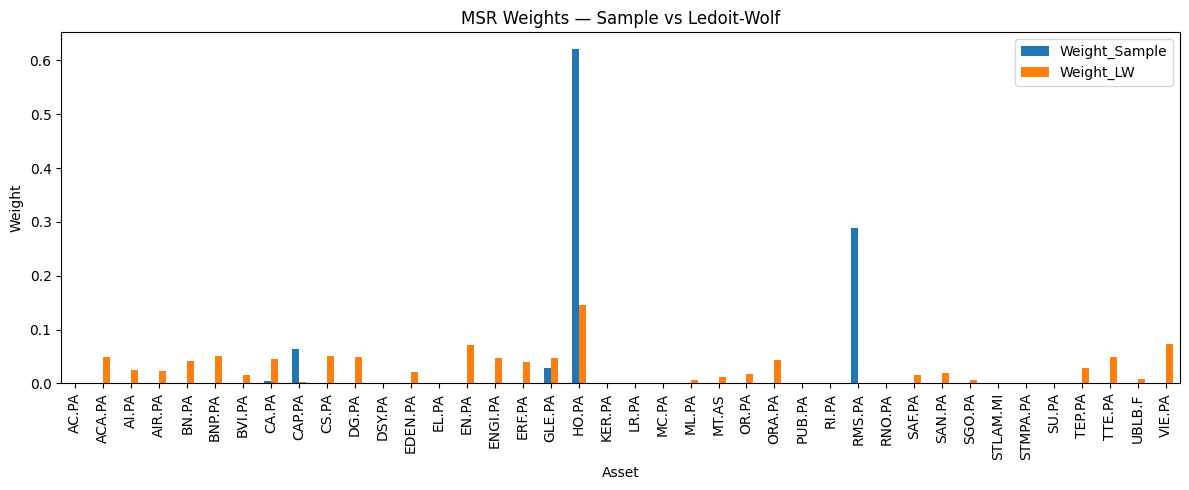

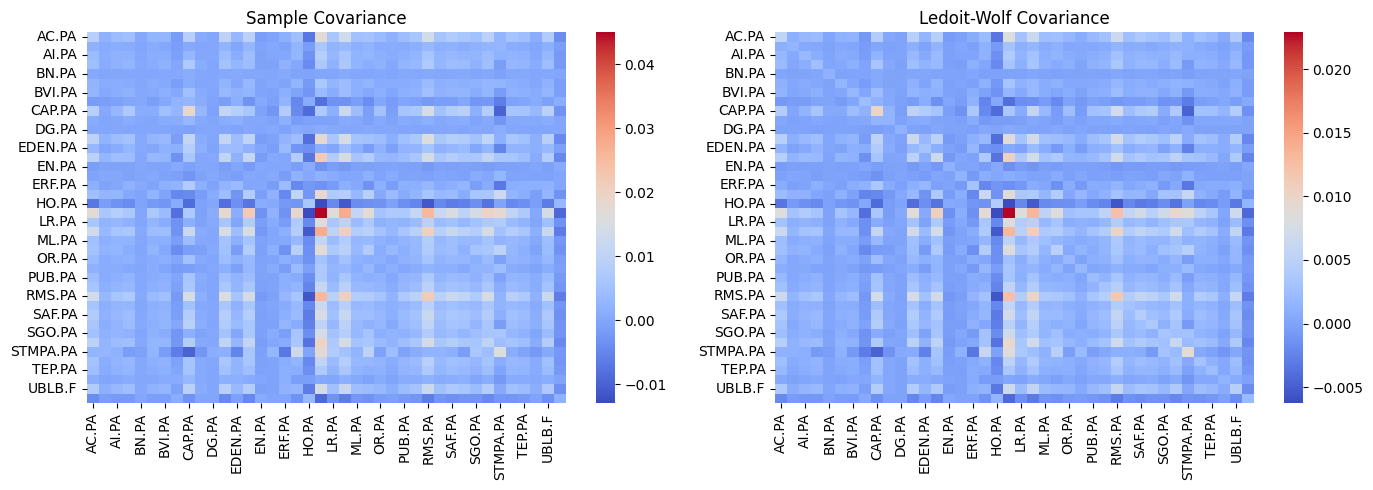

In [5]:
from index_management.strategy.Manager import MaxSharpeRatioPortfolio
import matplotlib.pyplot as plt
import seaborn as sns

msr = MaxSharpeRatioPortfolio(TARGET_DATE)
prior_msr, df_msr = msr.calculate_weights()

df_msr.set_index("Asset", inplace=True)
df_msr.plot(kind="bar", figsize=(12, 5), title="MSR Weights — Sample vs Ledoit-Wolf")
plt.ylabel("Weight")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(msr.df_sample_cov_matrix, annot=False, cmap="coolwarm", ax=axes[0]).set_title("Sample Covariance")
sns.heatmap(msr.df_LedoitWolf_cov_matrix, annot=False, cmap="coolwarm", ax=axes[1]).set_title("Ledoit-Wolf Covariance")
plt.tight_layout()
plt.show()

### 3c · Strategy C — PCA-MSR

PCA first reduces the 40-stock return space to **k principal components** (auto-selected to explain ≥90% of variance). The MSR optimiser then works on the cleaner k×k factor covariance, and the resulting factor weights are projected back to individual stocks via the PCA loadings matrix.

**Key difference vs Strategy B:** the covariance matrix handed to the optimiser is k×k (well-conditioned) rather than 40×40 (noisy with limited history), producing more diversified weights.

In [ ]:
from index_management.strategy.Manager import PCAMaxSharpeRatioPortfolio

pca_msr = PCAMaxSharpeRatioPortfolio(TARGET_DATE)
prior_pca, df_pca = pca_msr.calculate_weights()

print(f"Components selected: {pca_msr.n_components_used}  "
      f"(explaining {pca_msr.explained_variance_pct:.1%} of variance)")
print(f"Non-zero stocks:     {(df_pca['Weight_PCA'] > 0).sum()} / {len(df_pca)}")
print(f"Weight sum:          {df_pca['Weight_PCA'].sum():.6f}")
df_pca.sort_values("Weight_PCA", ascending=False).head(10)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ── Explained variance scree plot ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cumvar = np.cumsum(pca_msr.explained_variance_ratio_)
axes[0].bar(range(1, len(cumvar) + 1), pca_msr.explained_variance_ratio_,
            color="steelblue", alpha=0.7, label="Individual")
axes[0].step(range(1, len(cumvar) + 1), cumvar, where="mid",
             color="darkorange", lw=2, label="Cumulative")
axes[0].axvline(pca_msr.n_components_used, color="red", ls="--", lw=1.5,
                label=f"k={pca_msr.n_components_used}")
axes[0].axhline(pca_msr.variance_threshold, color="grey", ls=":", lw=1)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree Plot — variance per PC")
axes[0].legend(fontsize=9)

# ── Weight comparison: B vs C (top 15 by PCA weight) ──────────────────────
# df_msr already has "Asset" as index (set_index was called in the MSR cell)
top = df_pca.sort_values("Weight_PCA", ascending=False).head(15)["Asset"].tolist()
df_msr_top = df_msr.loc[[s for s in top if s in df_msr.index], "Weight_LW"]
df_pca_top = df_pca.set_index("Asset").loc[top, "Weight_PCA"]

x = np.arange(len(top))
w = 0.38
axes[1].bar(x - w/2, df_msr_top.reindex(top).fillna(0), w, label="B — MSR (LW)", color="steelblue", alpha=0.85)
axes[1].bar(x + w/2, df_pca_top, w, label="C — PCA-MSR", color="darkorange", alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(top, rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Weight")
axes[1].set_title("Strategy B vs C — top 15 stocks by PCA weight")
axes[1].legend(fontsize=9)

# ── Non-zero stock count comparison ───────────────────────────────────────
labels = ["A — Cap Weight\n(all 40)", "B — MSR (LW)", "C — PCA-MSR"]
counts = [
    (df_cw["Weights_new"] > 0).sum(),
    (df_msr["Weight_LW"] > 0).sum(),
    (df_pca["Weight_PCA"] > 0).sum(),
]
colors = ["#4e79a7", "#f28e2b", "#59a14f"]
axes[2].bar(labels, counts, color=colors, alpha=0.85)
axes[2].set_ylabel("Non-zero positions")
axes[2].set_title("Effective number of holdings")
for i, v in enumerate(counts):
    axes[2].text(i, v + 0.3, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 4 · Valuation

Converts weights and end-of-quarter prices into a share allocation for a $1B notional portfolio.

In [6]:
from index_management.valuation.Manager import Valuation

val_cw = Valuation(TARGET_DATE, "cw")
df_alloc_cw = val_cw.valuation_quarterly()
print("Cap-weight quarterly allocation:")
df_alloc_cw.head(10)

Cap-weight quarterly allocation:


,Symbol,NumShares
0,AC.PA,99358.0
1,ACA.PA,1281048.0
2,AI.PA,248712.0
3,AIR.PA,288143.0
4,BN.PA,291268.0
5,BNP.PA,453199.0
6,BVI.PA,186886.0
7,CA.PA,282298.0
8,CAP.PA,67590.0
9,CS.PA,951677.0


In [7]:
val_msr = Valuation(TARGET_DATE, "msr")
df_alloc_msr = val_msr.valuation_quarterly()
print("MSR quarterly allocation:")
df_alloc_msr.head(10)

MSR quarterly allocation:


,Symbol,NumShares
0,AC.PA,0.0
1,ACA.PA,2863858.0
2,AI.PA,141876.0
3,AIR.PA,137330.0
4,BN.PA,581127.0
5,BNP.PA,667679.0
6,BVI.PA,534902.0
7,CA.PA,3368641.0
8,CAP.PA,13082.0
9,CS.PA,1311760.0
